## Imports (+ utils: function, classes)

In [19]:
from os.path import exists
from io import StringIO
from functools import reduce
from IPython.display import display
from tqdm import tqdm_notebook, tqdm

import numpy as np
from numpy.typing import ArrayLike
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

from genome_tools.genomic_interval import GenomicInterval
from genome_tools.data.extractors import FastaExtractor
from genome_tools.data.anndata import read_zarr_backed
from vinson.utils.helpers import replace_at
from vinson.utils.sequence_utils import one_hot_encode
from vinson.utils.inference import assemble_batch
from vinson.from_config import read_configs, dhs_model_from_config
from vinson.postprocessing.interpretation import ModelWrapper

from genome_tools.plotting.ideogram import read_ideogram
from genome_tools.plotting.modular_plot import IntervalPlotter
from genome_tools.plotting.modular_plot.plot_components.prediction import PredictedSignalComponent
from genome_tools.plotting.modular_plot.plot_components.basic import TrackComponent, IdeogramComponent, GencodeComponent
from genome_tools.plotting.modular_plot.plot_components.prediction import (
    AttributionsFromBatchComponent,
    AttributionsWeightedMotifHitsFromBatchComponent
)


In [7]:
from matplotlib import rcParams

rcParams["axes.titlesize"] = "large"
rcParams["axes.titlepad"] = 2

rcParams["axes.linewidth"] = 0.5
rcParams["axes.labelsize"] = "medium"
rcParams["axes.labelpad"] = 1

rcParams["xtick.labelsize"] = "medium"
rcParams["ytick.labelsize"] = "medium"

rcParams["xtick.major.size"] = 2
rcParams["ytick.major.size"] = 2
rcParams["xtick.major.width"] = 0.5
rcParams["ytick.major.width"] = 0.5
rcParams["xtick.major.pad"] = 1
rcParams["ytick.major.pad"] = 1

rcParams["grid.linewidth"] = 0.5

rcParams["legend.fontsize"] = "medium"
rcParams["legend.labelspacing"] = 0.5

rcParams["font.size"] = 6

rcParams["lines.linewidth"] = 0.75


rcParams['figure.dpi'] = 300

## Set up your paths

In [25]:
device = 'cuda'

fasta_file = '/mnt/calc/sbushuev/genomes/hg38/hg38.fa' # genome
gencode_annotation_file = '/mnt/calc/sbushuev/genomes/hg38/gencode.v49.basic.annotation.sorted.gff3.gz' #'/mnt/calc/sbushuev/genomes/hg38/gencode.v49.basic.annotation.sorted.gff3.gz'
idg_path = ''

config_path= '/mnt/calc/homes/sbushuev/dhs_project/configs/FinalVersion/MAR06_8mln_long.yaml' # path to model's config .yaml file used to train model
checkpoint_path = '/mnt/calc/homes/sbushuev/dhs_project/checkpoints/9epochs_8mln_JUN29_best_epoch=8.ckpt' # path to .ckpt file

zarr_anndata_path = '/mnt/calc/sbushuev/dhs_project/anndata/reference_anndata.human.stripped_layers.zarr'

motif_annotations_path = '/mnt/calc/homes/sbushuev/dhs_project/examples/moods_scans_ref.merged.sorted.bed.gz'
motif_metadata_path = '/mnt/calc/homes/sbushuev/dhs_project/examples/motifs_meta.tsv'


if not exists(zarr_anndata_path):
    zarr_anndata_path = 'https://regulome.altius.org/data/release_20260818/human/consensus_dhs/human_reference/human_reference_anndata.zarr/'
if not exists(idg_path):
    idg_path = 'https://resources.altius.org/~sabramov/collaborations/vinson/examples/cytoBandIdeo.txt'
if not exists(motif_metadata_path):
    motif_metadata_path = 'https://resources.altius.org/~sabramov/collaborations/vinson/examples/motifs_meta.tsv'


In [26]:
anndata = read_zarr_backed(zarr_anndata_path)
motif_metadata = pd.read_table(motif_metadata_path, index_col=0)
idg = read_ideogram(idg_path)
### temp
motif_metadata['pfm'] = motif_metadata['pfm'].str.replace('/home/jvierstra/public_html/', 'https://resources.altius.org/~jvierstra/')
motif_metadata['pfm'] = motif_metadata['pfm'].str.replace('projects/projects', 'projects')

# motif_metadata.head()


/mnt/calc/sbushuev/.conda/envs/dhs_env/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing sparse_dataset from `anndata.experimental` is deprecated. Import anndata.io.sparse_dataset instead.
  warnings.warn(msg, FutureWarning)
/mnt/calc/sbushuev/.conda/envs/dhs_env/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  warnings.warn(msg, FutureWarning)
/mnt/calc/sbushuev/.conda/envs/dhs_env/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  warnings.warn(msg, FutureWarning)
/mnt/calc/sbushuev/.conda/envs/dhs_env/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  warnings.warn(msg, FutureWarning)
/mnt/calc/sbushuev/.conda/

In [34]:
model_config = read_configs(config_path)
model_predict = dhs_model_from_config(model_config, checkpoint_path).to('cuda')
model_wrapper = ModelWrapper(model_predict).eval().to(device)

chosen_sample = 'AG95384'
interval = GenomicInterval.from_ucsc('chr14:72685616-72686960')

## prepare paths to extract profile
base_path = 'https://regulome.altius.org/data/per_sample/' 
online_track_path = base_path+ chosen_sample + '/' + chosen_sample + '.normalized_density.bw' 

idg_path = 'https://resources.altius.org/~sabramov/collaborations/vinson/examples/cytoBandIdeo.txt'


/mnt/calc/sbushuev/.conda/envs/dhs_env/lib/python3.12/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [39]:
plot_components = [
    IdeogramComponent(
        interval_key='big', # interval_key for which the component should be ploted
        height=0.03, # height, handled by IntervalPlotter, by default, in inches,
        margins=0,
    ),
    GencodeComponent(
        interval_key='big',
        height=0.05,
        margins=(0, 0.02) # margins: either one number or a tuple of two: top and bottom
    ),
    TrackComponent(name=f'TrueSignalComponent_{chosen_sample}',
                    interval_key='big',
                    signal_file = online_track_path,                    
                    color='tab:blue',
                    height=0.1,
                    margins=(0, 0.05),
                ),
    PredictedSignalComponent(
                name=f'PredictedSignalComponent_{chosen_sample}',
                interval_key='big',
                sample_id=chosen_sample,
                color='tab:orange',
                height=0.1,
                margins=(0, 0.05),
            ),

    AttributionsFromBatchComponent(
        interval_key='small',
        height=0.06,
        margins=0,
        n_shuffles=100,
    ),
    AttributionsWeightedMotifHitsFromBatchComponent(
        interval_key='small',
        height=0.06,
        margins=0,
        n_shuffles=100,
        motif_annotations_path=motif_annotations_path
    )
    
]

interval_plotter = IntervalPlotter(
    plot_components=plot_components,
    ideogram_data=idg,
    model_wrapper=model_wrapper,
    motif_meta=motif_metadata,
    fasta_file=fasta_file,
    gencode_annotation_file=gencode_annotation_file,
)

Found overlapping component loader kwargs:
Argument 'signal_file' used by: TrueSignalComponent_AG95384, PredictedSignalComponent_AG95384
Argument 'model_wrapper' used by: PredictedSignalComponent_AG95384, AttributionsFromBatchComponent, AttributionsWeightedMotifHitsFromBatchComponent
Argument 'sample_id' used by: PredictedSignalComponent_AG95384, AttributionsFromBatchComponent
Argument 'anndata' used by: PredictedSignalComponent_AG95384, AttributionsFromBatchComponent
Argument 'fasta_file' used by: PredictedSignalComponent_AG95384, AttributionsFromBatchComponent
Argument 'genotype_file' used by: PredictedSignalComponent_AG95384, AttributionsFromBatchComponent
Argument 'print_convergence_deltas' used by: AttributionsFromBatchComponent, AttributionsWeightedMotifHitsFromBatchComponent
Argument 'n_shuffles' used by: AttributionsFromBatchComponent, AttributionsWeightedMotifHitsFromBatchComponent
Argument 'random_state' used by: AttributionsFromBatchComponent, AttributionsWeightedMotifHitsFr

In [40]:
interval_dict = {
    'big': interval.zoom(-7),
    'small': interval.zoom(10)
}

annotation_regions = [
    GenomicInterval.from_ucsc('chr14:72686255-72686281'),
    GenomicInterval.from_ucsc('chr14:72686328-72686354'),
] # regions where to look for motif scans


plotter_data = interval_plotter.get_interval_data(
    interval_dict,
    batch=assemble_batch(
        'AG95384',
        interval=interval,
        embeddings=anndata.obsm['motif_embeddings'],
        fasta=fasta_file
    ),
    # signal_file=human_anndata.obs.loc['AG95384', 'normalized_density_bw'],
    anndata=anndata,
    annotation_regions=annotation_regions,

)

Loading data:  67%|██████▋   | 4/6 [00:05<00:02,  1.30s/it]/mnt/calc/sbushuev/.conda/envs/dhs_env/lib/python3.12/site-packages/tangermeme/deep_lift_shap.py:745: RuntimeWarning: Convergence deltas too high: tensor([2.6687, 1.6386, 1.5074, 0.7701, 0.2544, 1.7488, 1.6378, 2.0120, 1.8180,
        1.7784, 0.9756, 0.7902, 1.7993, 1.7969, 1.5316, 1.8746, 2.7008, 1.0188,
        1.9034, 1.6741, 2.0415, 2.4603, 1.8229, 2.5644, 2.1878, 1.5020, 1.9676,
        1.5144, 2.2348, 2.1788, 1.5486, 1.9049], device='cuda:0',
       grad_fn=<AbsBackward0>)
  warnings.warn("Convergence deltas too high: " +
/mnt/calc/sbushuev/.conda/envs/dhs_env/lib/python3.12/site-packages/tangermeme/deep_lift_shap.py:745: RuntimeWarning: Convergence deltas too high: tensor([1.7442, 2.4414, 2.0885, 1.9067, 1.6586, 1.4173, 1.0936, 1.9355, 2.4195,
        2.2652, 1.6683, 1.7601, 2.3671, 1.3640, 1.4911, 1.5354, 2.3789, 1.8200,
        1.9669, 1.6482, 2.4189, 1.7711, 1.7544, 2.5411, 1.5954, 2.1562, 1.4721,
        2.0429, 1.61

PlotComponent AttributionsWeightedMotifHitsFromBatchComponent returned multiple axes. Using the first one when adding a connector.
PlotComponent AttributionsWeightedMotifHitsFromBatchComponent returned multiple axes. Using the first one when adding a connector.
PlotComponent AttributionsWeightedMotifHitsFromBatchComponent returned multiple axes. Using the first one when adding a connector.
PlotComponent AttributionsWeightedMotifHitsFromBatchComponent returned multiple axes. Using the first one when adding a connector.


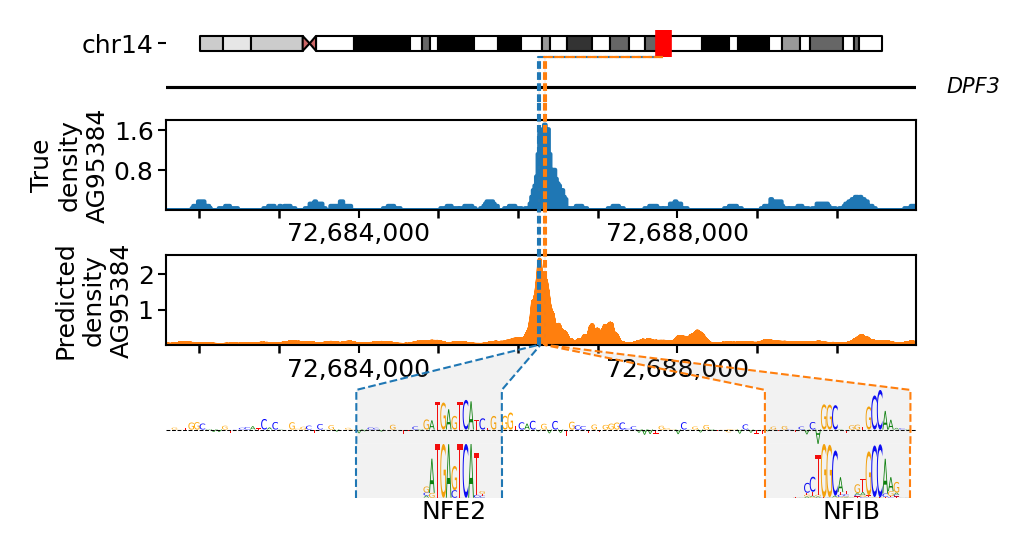

In [43]:
axes = interval_plotter.plot_interval(plotter_data, height_scale=3)

axes[2].set_ylabel(f'True\ndensity\n{chosen_sample}')
axes[3].set_ylabel(f'Predicted\ndensity\n{chosen_sample}')

for i, region in enumerate(annotation_regions):
    interval_plotter.plot_connector(
        axes,
        interval=region,
        lw=0,
        type='area',
        extend_to_bottom=True,
        alpha=0.1
    )

    interval_plotter.plot_connector(
        axes,
        interval=region,
        ls='--',
        c=f'C{i}',
        lw=0.5,
        type='line',
        extend_to_bottom=True
    )